In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('accepted_2007_to_2018Q4.csv',low_memory=False)
df.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [3]:
df.isnull().mean().sort_values(ascending=False).head(20)

member_id                                     1.000000
orig_projected_additional_accrued_interest    0.996173
hardship_end_date                             0.995171
hardship_start_date                           0.995171
hardship_type                                 0.995171
hardship_reason                               0.995171
hardship_status                               0.995171
deferral_term                                 0.995171
hardship_last_payment_amount                  0.995171
hardship_payoff_balance_amount                0.995171
hardship_loan_status                          0.995171
hardship_dpd                                  0.995171
hardship_length                               0.995171
payment_plan_start_date                       0.995171
hardship_amount                               0.995171
settlement_term                               0.984852
debt_settlement_flag_date                     0.984852
settlement_status                             0.984852
settlement

In [4]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])]
df['target'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)
print(f"Shape after filter: {df.shape}")
print(f"Default rate: {df['target'].mean():.2%}")

Shape after filter: (1345350, 152)
Default rate: 19.96%


In [5]:
features = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti', 'grade',
    'emp_length', 'home_ownership', 'purpose', 'fico_range_low',
    'open_acc', 'revol_util', 'revol_bal', 'mort_acc', 'pub_rec', 'target'
]
df = df[features].copy()
print(df.shape)
print(df.isnull().sum())

(1345350, 15)
loan_amnt             0
int_rate              0
annual_inc            0
dti                 374
grade                 0
emp_length        78516
home_ownership        0
purpose               0
fico_range_low        0
open_acc              0
revol_util          857
revol_bal             0
mort_acc          47281
pub_rec               0
target                0
dtype: int64


In [6]:
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df['emp_length'] = df['emp_length'].map(emp_map)
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)
df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)
df.dropna(inplace=True)
print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (1220127, 15)


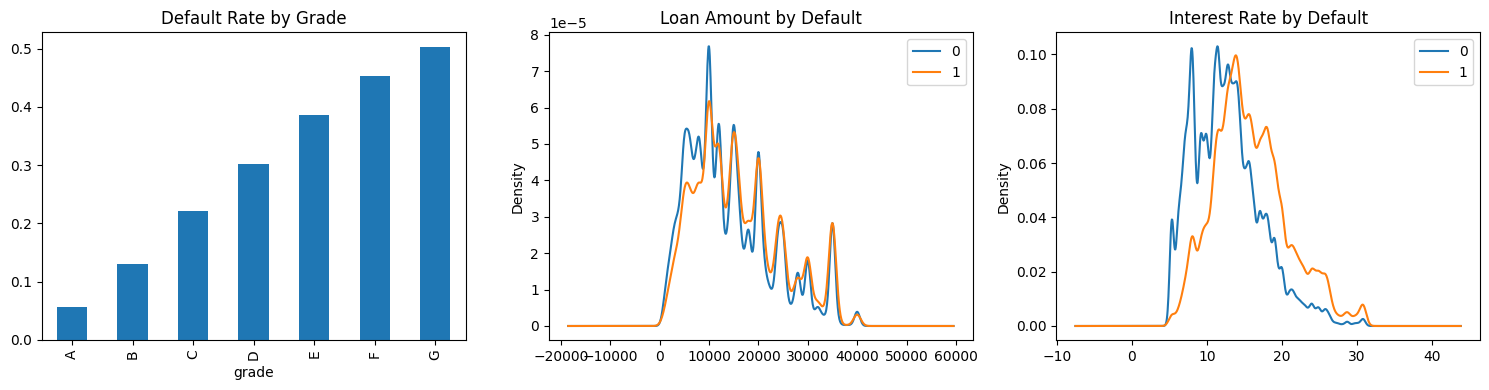

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby('grade')['target'].mean().plot(
    kind='bar', ax=axes[0], title='Default Rate by Grade')

df.groupby('target')['loan_amnt'].plot(
    kind='kde', ax=axes[1], legend=True, title='Loan Amount by Default')

df.groupby('target')['int_rate'].plot(
    kind='kde', ax=axes[2], legend=True, title='Interest Rate by Default')

plt.tight_layout()
plt.show()

In [15]:
import os
df.to_csv('processed/cleaned.csv', index=False)
print("Saved cleaned data")

Saved cleaned data
